In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
paths = ({
    'invoice_level_table': '../data/D3_invoice-level table.csv',
    'customer_features': '../data/D6_customer_features.csv',
    'figure1': '../outputs/D7_daily_rev_trend.png',
    'figure2': '../outputs/D7_top10_countries.png',
    'figure3': '../outputs/D7_aov_distribution.png',
    'figure4': '../outputs/D7_top20_customers.png'
})


In [3]:
df_invoice = pd.read_csv(paths['invoice_level_table'])
df_customer = pd.read_csv(paths['customer_features'])

#### 1.daily revenue trend (line)
The daily revenue follows an uprise general trend with periodic fluctuations.

In [16]:
# daily revenue calculation
df_invoice['invoice_first_date'] = pd.to_datetime(df_invoice['invoice_first_date'])
daily_revenue = df_invoice.resample('D', on='invoice_first_date').agg({'invoice_revenue': 'sum'}).reset_index()
daily_revenue.describe()

,invoice_first_date,invoice_revenue
count,374,374.000000
mean,2011-06-05 12:00:00,23827.293861
min,2010-12-01 00:00:00,0.000000
25%,2011-03-04 06:00:00,10999.510000
50%,2011-06-05 12:00:00,21926.175000
75%,2011-09-06 18:00:00,32841.720000
max,2011-12-09 00:00:00,184349.280000
std,NaN,19713.216739


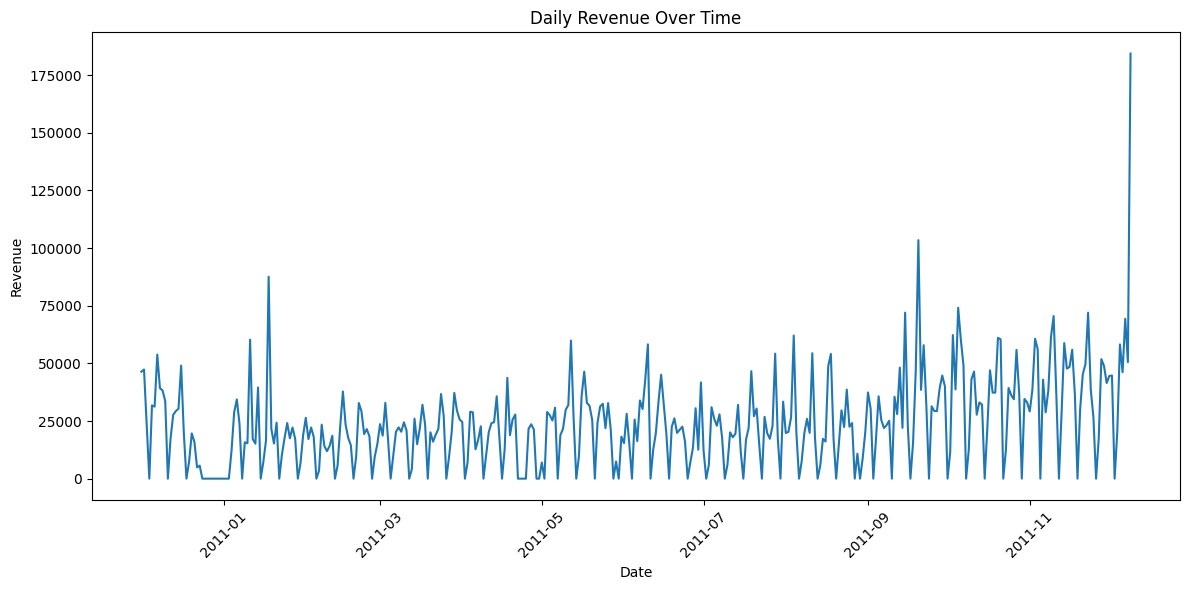

<Figure size 640x480 with 0 Axes>

In [17]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_revenue, x='invoice_first_date', y='invoice_revenue')
plt.title('Daily Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.savefig(paths['figure1'])

#### 2. top 10 countries by revenue (bar)
Insight: UK have revenue well above any other countries.

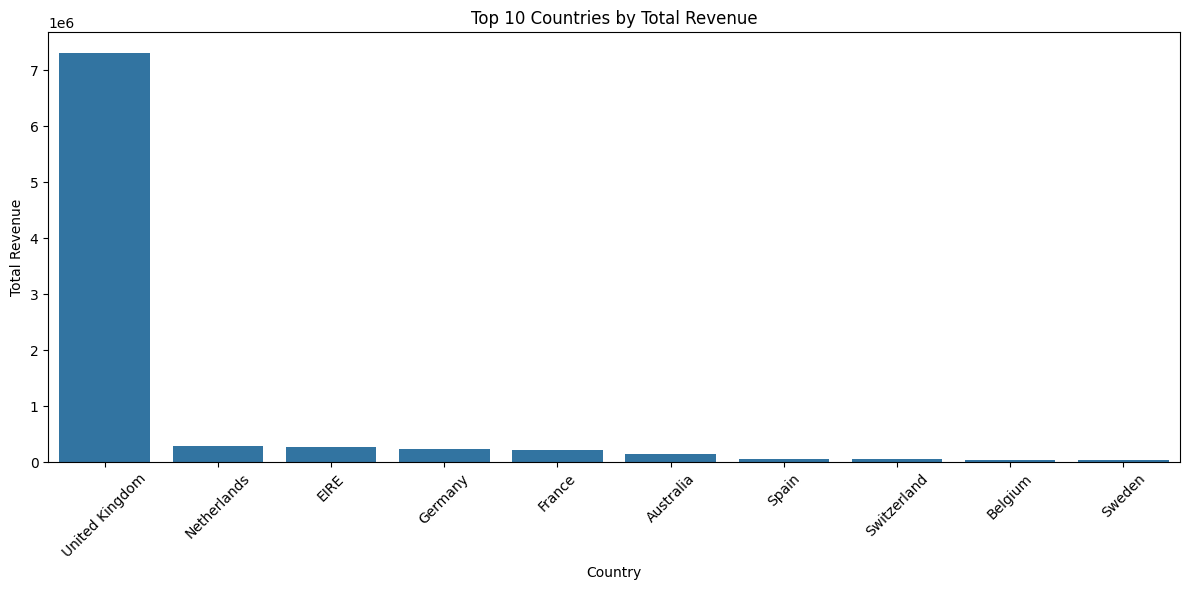

<Figure size 640x480 with 0 Axes>

In [14]:
top10 = df_invoice.groupby('country')['invoice_revenue'].sum().nlargest(10).reset_index()
country_order = top10.sort_values('invoice_revenue', ascending=False)['country']

plt.figure(figsize=(12, 6))
sns.barplot(data=top10, x='country', y='invoice_revenue', order=country_order)
plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.savefig(paths['figure2'])

#### 3. AOV distribution (hist, KDE)
Insight: 75% of AOV is under $500 per order, while there are some outlier values on the higher end.

In [19]:
df_customer['avg_aov'].describe()

count     4338.000000
mean       419.166289
std       1796.537944
min          3.450000
25%        178.625000
50%        293.900000
75%        430.113750
max      84236.250000
Name: avg_aov, dtype: float64

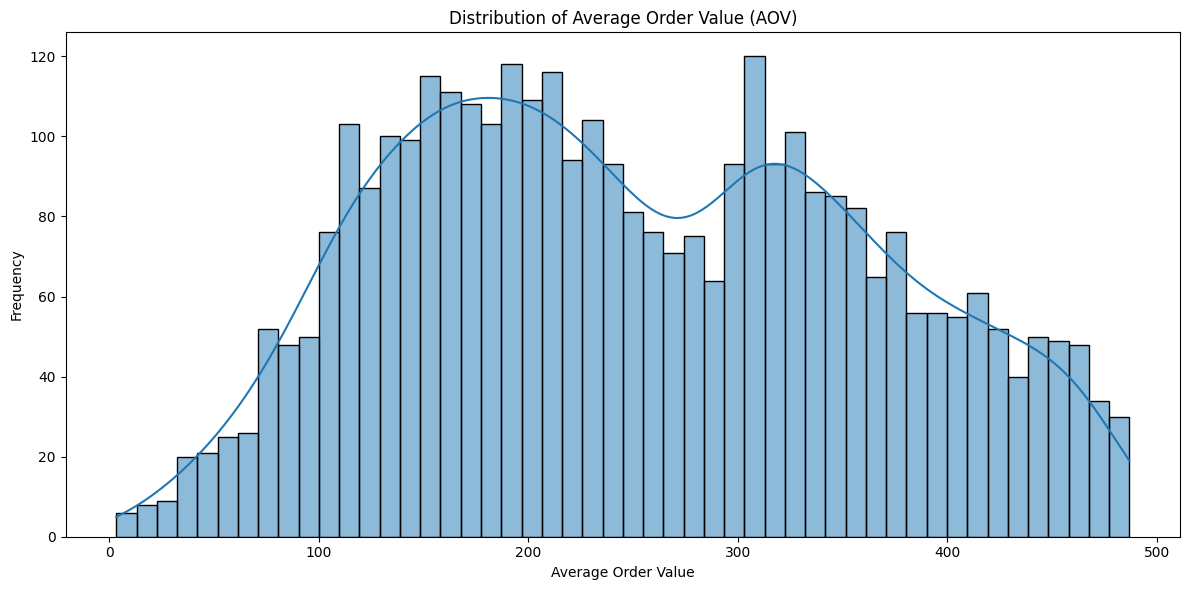

<Figure size 640x480 with 0 Axes>

In [ ]:
# plot graph excluding top ~25%
plt.figure(figsize=(12, 6))
sns.histplot(df_customer['avg_aov'].nsmallest(3500), bins=50, kde=True)
plt.title('Distribution of Average Order Value (AOV)')
plt.xlabel('Average Order Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

plt.savefig(paths['figure3'])

#### 4. top 20 customers by total revenue (bar)

insights: Only the top 7 customers are above average, meaning revenue is concentrated in a few customers. 

In [ ]:
top20 = df_customer.sort_values('total_revenue', ascending=False).head(20)
top20['total_revenue'].describe()

71918.58


count        20.00000
mean     106302.24000
std       69542.78066
min       50491.81000
25%       58746.99250
50%       71918.58000
75%      129642.16250
max      280206.02000
Name: total_revenue, dtype: float64

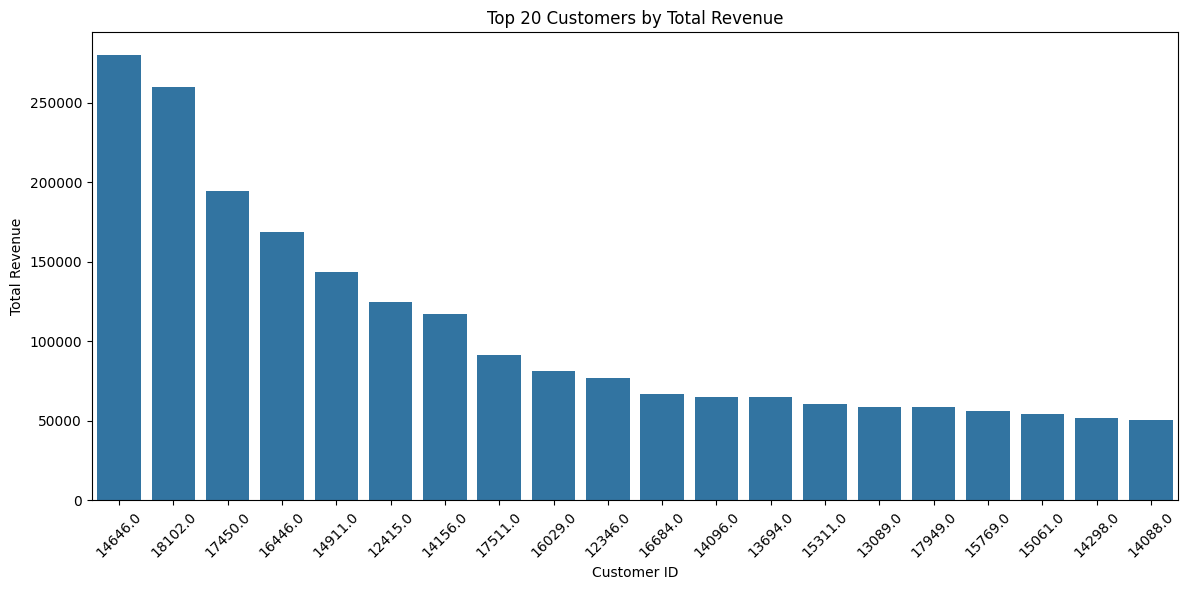

<Figure size 640x480 with 0 Axes>

In [15]:
customer_order = top20['customer_id']

plt.figure(figsize=(12, 6))
sns.barplot(data=top20, x='customer_id', y='total_revenue', order=customer_order)
plt.title('Top 20 Customers by Total Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.savefig(paths['figure4'])